### **Flowers Detection Project**

### **1.Load Library**

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import splitfolders
from torchvision.utils import make_grid
from torchsummary import summary
from torchvision import models,datasets,transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

### **Define Transform**

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **2.Prepare Train and Test Sets and DataLoader**

In [3]:
splitfolders.ratio("dataset",output = "Output_two",seed = 42,ratio = (0.8,0.2))

Copying files: 5856 files [01:07, 86.81 files/s] 


In [7]:
train = datasets.ImageFolder("Output_two/train",transform = transform)
test = datasets.ImageFolder("Output_two/val",transform = transform)

In [8]:
print(len(train))
print(len(test))

4684
1172


In [9]:
train_loader = DataLoader(train,batch_size = 32,shuffle = True,drop_last = True)
test_loader = DataLoader(test,batch_size = 32,shuffle = False,drop_last = True)

### **3.Display Batch of Image**

In [10]:
for image,label in train_loader:
    break
print(image.shape)
print(image)
print("="*50)
print(label.shape)
print(label)

torch.Size([32, 3, 224, 224])
tensor([[[[-1.5014, -1.5185, -1.5185,  ..., -1.6042, -1.6042, -1.6042],
          [-1.5014, -1.5185, -1.5185,  ..., -1.6042, -1.6042, -1.6042],
          [-1.5185, -1.5185, -1.5185,  ..., -1.6213, -1.6213, -1.6213],
          ...,
          [-1.4500, -1.4672, -1.4843,  ..., -1.4843, -1.4672, -1.4500],
          [-1.2445, -1.4672, -1.4843,  ..., -1.4843, -1.4672, -1.2445],
          [-1.4843, -1.4672, -1.4843,  ..., -1.4843, -1.4672, -1.4843]],

         [[-1.4055, -1.4230, -1.4230,  ..., -1.5105, -1.5105, -1.5105],
          [-1.4055, -1.4230, -1.4230,  ..., -1.5105, -1.5105, -1.5105],
          [-1.4230, -1.4230, -1.4230,  ..., -1.5280, -1.5280, -1.5280],
          ...,
          [-1.3529, -1.3704, -1.3880,  ..., -1.3880, -1.3704, -1.3529],
          [-1.1429, -1.3704, -1.3880,  ..., -1.3880, -1.3704, -1.1429],
          [-1.3880, -1.3704, -1.3880,  ..., -1.3880, -1.3704, -1.3880]],

         [[-1.1770, -1.1944, -1.1944,  ..., -1.2816, -1.2816, -1.2816],


In [11]:
classes = train.classes
print(classes)

['NORMAL', 'PNEUMONIA']


Labels  [1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 0]
Classes : PNEUMONIA PNEUMONIA PNEUMONIA PNEUMONIA PNEUMONIA PNEUMONIA NORMAL PNEUMONIA PNEUMONIA PNEUMONIA NORMAL PNEUMONIA PNEUMONIA PNEUMONIA PNEUMONIA NORMAL PNEUMONIA PNEUMONIA NORMAL PNEUMONIA PNEUMONIA PNEUMONIA NORMAL PNEUMONIA PNEUMONIA NORMAL PNEUMONIA NORMAL NORMAL PNEUMONIA PNEUMONIA NORMAL


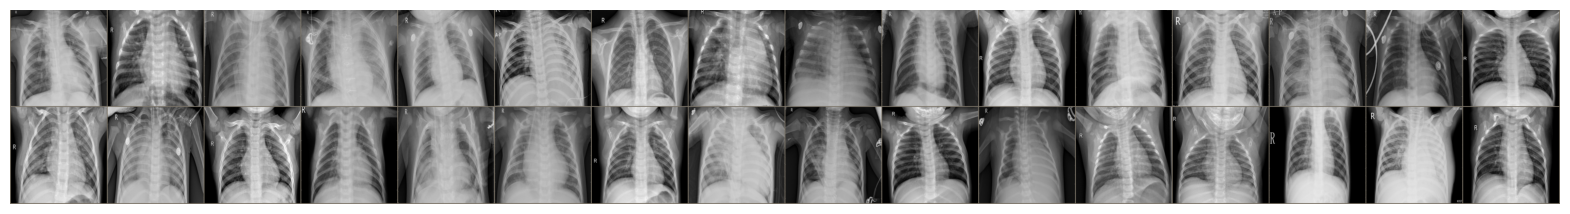

In [12]:
# print the labels

print("Labels ",label.numpy())
print("Classes :",*np.array([classes[i] for i in label]))

# Make a grid of images
im = make_grid(image, nrow=16)

# Inverse normalize the images
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

im_inv = inv_normalize(im)

# Show the image
plt.figure(figsize=(20,16))
plt.imshow(np.transpose(im_inv.numpy(), (1,2,0)))
plt.axis("off")
plt.show()

### **4.Import EfficientNet-B0**

In [13]:
weight = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights = weight)


In [14]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

### **5.Freeze all layer**

In [15]:
# freeze all layers

for param in model.parameters():
    param.requires_grad = False

### **6.Unfreeze the last layer**

In [16]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features,2)

In [17]:
print(model.classifier[1])

Linear(in_features=1280, out_features=2, bias=True)


### **7.Early stopping Criteria**

In [18]:
import numpy as np


class EarlyStoppingCriterion:

    def __init__(self, patience=5, delta=0):

        self.patience = patience
        self.delta = delta

        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):

        score = -val_loss

        # First epoch
        if self.best_score is None:

            self.best_score = score

        # No improvement
        elif score < self.best_score + self.delta:

            self.counter += 1

            print(
                f"EarlyStopping Counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        # Improvement
        else:

            self.best_score = score
            self.counter = 0

### **8.Training and Testing**

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
import torch
import torch.nn as nn


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ============================================================
# 2. MODEL SETUP
# ============================================================

# Freeze all EfficientNet layers
for param in model.parameters():
    param.requires_grad = False


# Replace the final classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)


# Make classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True


# IMPORTANT:
# Move the complete model to GPU
model = model.to(device)


print("\nModel device:")
print(next(model.parameters()).device)

print("\nClassifier:")
print(model.classifier)


# ============================================================
# 3. HYPERPARAMETERS
# ============================================================

learning_rate = 0.001
epochs = 50


# ============================================================
# 4. LOSS FUNCTION
# ============================================================

loss_func = nn.CrossEntropyLoss()


# ============================================================
# 5. OPTIMIZER
# ============================================================

# Only optimize trainable parameters
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    momentum=0.9
)


# ============================================================
# 6. STORE RESULTS
# ============================================================

train_losses = []
val_losses = []

train_accuracy = []
val_accuracy = []


# ============================================================
# 7. EARLY STOPPING
# ============================================================

class EarlyStoppingCriterion:

    def __init__(self, patience=5, delta=0):

        self.patience = patience
        self.delta = delta

        self.counter = 0
        self.best_score = None

        self.early_stop = False

    def __call__(self, val_loss):

        score = -val_loss

        # First validation loss
        if self.best_score is None:

            self.best_score = score

        # Validation loss did not improve
        elif score < self.best_score + self.delta:

            self.counter += 1

            print(
                f"EarlyStopping counter: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

        # Validation loss improved
        else:

            self.best_score = score
            self.counter = 0


early_stopping = EarlyStoppingCriterion(
    patience=5,
    delta=0
)


# ============================================================
# 8. BEST MODEL STORAGE
# ============================================================

best_val_loss = float("inf")

best_model_state = None


# ============================================================
# 9. TRAINING LOOP
# ============================================================

for epoch in range(epochs):


    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        # Move data to GPU
        X_batch = X_batch.to(device)

        y_batch = y_batch.long().to(device)


        # Clear previous gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(X_batch)


        # Calculate loss
        loss = loss_func(
            outputs,
            y_batch
        )


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        running_loss += loss.item()


        # ----------------------------------------------------
        # Accuracy
        # ----------------------------------------------------

        _, predicted = torch.max(
            outputs,
            1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()


        # ----------------------------------------------------
        # Batch progress
        # ----------------------------------------------------

        if batch_idx % 10 == 0:

            print(
                f"Epoch [{epoch + 1}/{epochs}] "
                f"Batch [{batch_idx + 1}/{len(train_loader)}]"
            )


    # ========================================================
    # TRAINING EPOCH RESULTS
    # ========================================================

    epoch_train_loss = (
        running_loss / len(train_loader)
    )

    epoch_train_acc = (
        100 * correct / total
    )


    train_losses.append(
        epoch_train_loss
    )

    train_accuracy.append(
        epoch_train_acc
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0

    correct = 0
    total = 0


    with torch.no_grad():

        # IMPORTANT:
        # Validation uses val_loader, NOT test_loader
        for X_batch, y_batch in val_loader:

            # Move data to GPU
            X_batch = X_batch.to(device)

            y_batch = y_batch.long().to(device)


            # Forward pass
            outputs = model(X_batch)


            # Calculate validation loss
            loss = loss_func(
                outputs,
                y_batch
            )


            running_val_loss += loss.item()


            # Accuracy
            _, predicted = torch.max(
                outputs,
                1
            )


            total += y_batch.size(0)

            correct += (
                predicted == y_batch
            ).sum().item()


    # ========================================================
    # VALIDATION EPOCH RESULTS
    # ========================================================

    epoch_val_loss = (
        running_val_loss / len(val_loader)
    )

    epoch_val_acc = (
        100 * correct / total
    )


    val_losses.append(
        epoch_val_loss
    )

    val_accuracy.append(
        epoch_val_acc
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

        print("Best model saved!")


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    early_stopping(
        epoch_val_loss
    )


    # ========================================================
    # EPOCH RESULT
    # ========================================================

    print(
        f"\nEpoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )

    print("-" * 80)


    # ========================================================
    # STOP TRAINING
    # ========================================================

    if early_stopping.early_stop:

        print("\nEarly Stopping Triggered!")

        break


# ============================================================
# 10. RESTORE BEST MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    model = model.to(device)

    print("\nBest model restored.")


# ============================================================
# 11. TRAINING COMPLETE
# ============================================================

print("\nTraining completed!")

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

print(
    f"Epochs Completed: {len(train_losses)}"
)

Using device: cuda

Model device:
cuda:0

Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [21]:
torch.save(model.state_dict(), "efficientnet_b0_flowers.pth")

print("Model saved successfully!")

Model saved successfully!


### **Load the saved model**

In [1]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Create model
model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)


# 5 flower classes
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    5
)


# Load trained weights
model.load_state_dict(
    torch.load(
        "efficientnet_b0_flowers.pth",
        weights_only=True
    )
)


# Move to GPU/CPU
model = model.to(device)


# Evaluation mode
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [2]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", torch.cuda.get_device_properties(0).total_memory / 1024**3, "GB")

PyTorch: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory: 5.99658203125 GB


In [2]:
print(
    "Allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 3),
    "GB"
)

print(
    "Reserved:",
    round(torch.cuda.memory_reserved() / 1024**3, 3),
    "GB"
)

Allocated: 0.0 GB
Reserved: 0.0 GB


In [19]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

# Move model to GPU
model = model.to(device)

print("Model device:", next(model.parameters()).device)

# Get ONE batch
X_batch, y_batch = next(iter(train_loader))

print("Input:", X_batch.shape)
print("Input device:", X_batch.device)

# Move batch to GPU
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

print("Batch moved to GPU")

# Forward pass
with torch.no_grad():
    outputs = model(X_batch)

print("Forward pass successful!")
print("Output shape:", outputs.shape)

print(
    "GPU allocated:",
    torch.cuda.memory_allocated() / 1024**3,
    "GB"
)

print(
    "GPU reserved:",
    torch.cuda.memory_reserved() / 1024**3,
    "GB"
)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Model device: cuda:0
Input: torch.Size([32, 3, 224, 224])
Input device: cpu
Batch moved to GPU
Forward pass successful!
Output shape: torch.Size([32, 2])
GPU allocated: 0.041049957275390625 GB
GPU reserved: 0.48828125 GB


In [20]:
import torch
import torch.nn as nn

# Clear previous GPU cache
torch.cuda.empty_cache()

# Get one batch
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

# Loss
criterion = nn.CrossEntropyLoss()

# Make sure model is in training mode
model.train()

# Forward
outputs = model(X_batch)

# Calculate loss
loss = criterion(outputs, y_batch)

print("Loss:", loss.item())

# Backward
loss.backward()

print("Backward pass successful!")

print(
    "GPU allocated:",
    torch.cuda.memory_allocated() / 1024**3,
    "GB"
)

print(
    "GPU reserved:",
    torch.cuda.memory_reserved() / 1024**3,
    "GB"
)

Loss: 0.7187160849571228
Backward pass successful!
GPU allocated: 0.049757957458496094 GB
GPU reserved: 0.48828125 GB


In [21]:
# Clear gradients
model.zero_grad()

# Create optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9
)

# Get one batch
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

model.train()

# Forward
outputs = model(X_batch)

# Loss
loss = criterion(outputs, y_batch)

# Backward
loss.backward()

# Optimizer update
optimizer.step()

print("Optimizer step successful!")
print("Loss:", loss.item())

print(
    "GPU allocated:",
    torch.cuda.memory_allocated() / 1024**3,
    "GB"
)

print(
    "GPU reserved:",
    torch.cuda.memory_reserved() / 1024**3,
    "GB"
)

Optimizer step successful!
Loss: 0.6684216260910034
GPU allocated: 0.04976797103881836 GB
GPU reserved: 0.48828125 GB


In [22]:
model.train()

train_loss = 0.0
correct = 0
total = 0

for X_batch, y_batch in train_loader:

    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    optimizer.zero_grad()

    outputs = model(X_batch)

    loss = criterion(outputs, y_batch)

    loss.backward()

    optimizer.step()

    train_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

train_loss /= len(train_loader)
train_accuracy = 100 * correct / total

print("1 epoch completed!")
print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

1 epoch completed!
Train Loss: 0.3901666233392611
Train Accuracy: 84.31078767123287


In [24]:
# ==========================
# Hyperparameters
# ==========================

learning_rate = 0.0001
epochs = 50


# ==========================
# Loss Function & Optimizer
# ==========================

loss_func = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=learning_rate
)


# ==========================
# Store Results
# ==========================

train_losses = []
val_losses = []

train_accuracy = []
val_accuracy = []


# ==========================
# Early Stopping
# ==========================

early_stopping = EarlyStoppingCriterion()


# ==========================
# Training Loop
# ==========================

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = loss_func(outputs, y_batch)

        loss.backward()

        optimizer.step()

        # Loss
        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

        # Batch progress
        if batch_idx % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Batch {batch_idx+1}/{len(train_loader)}"
            )

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    train_losses.append(epoch_train_loss)
    train_accuracy.append(epoch_train_acc)


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            outputs = model(X_batch)

            loss = loss_func(outputs, y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracy.append(epoch_val_acc)


    # ==========================
    # EARLY STOPPING
    # ==========================

    early_stopping(epoch_val_loss)


    # ==========================
    # EPOCH RESULT
    # ==========================

    print(
        f"\nEpoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )


    # ==========================
    # STOP TRAINING
    # ==========================

    if early_stopping.early_stop:

        print("\nEarly Stopping Triggered!")
        break

Epoch 1/50 | Batch 1/146
Epoch 1/50 | Batch 11/146
Epoch 1/50 | Batch 21/146
Epoch 1/50 | Batch 31/146
Epoch 1/50 | Batch 41/146
Epoch 1/50 | Batch 51/146
Epoch 1/50 | Batch 61/146
Epoch 1/50 | Batch 71/146
Epoch 1/50 | Batch 81/146
Epoch 1/50 | Batch 91/146
Epoch 1/50 | Batch 101/146
Epoch 1/50 | Batch 111/146
Epoch 1/50 | Batch 121/146
Epoch 1/50 | Batch 131/146
Epoch 1/50 | Batch 141/146

Epoch [1/50] | Train Loss: 0.2403 | Val Loss: 0.2193 | Train Acc: 90.99% | Val Acc: 91.84%
Epoch 2/50 | Batch 1/146
Epoch 2/50 | Batch 11/146
Epoch 2/50 | Batch 21/146
Epoch 2/50 | Batch 31/146
Epoch 2/50 | Batch 41/146
Epoch 2/50 | Batch 51/146
Epoch 2/50 | Batch 61/146
Epoch 2/50 | Batch 71/146
Epoch 2/50 | Batch 81/146
Epoch 2/50 | Batch 91/146
Epoch 2/50 | Batch 101/146
Epoch 2/50 | Batch 111/146
Epoch 2/50 | Batch 121/146
Epoch 2/50 | Batch 131/146
Epoch 2/50 | Batch 141/146

Epoch [2/50] | Train Loss: 0.2247 | Val Loss: 0.2104 | Train Acc: 92.19% | Val Acc: 92.19%
Epoch 3/50 | Batch 1/146
Epo

          CHEST X-RAY CLASSIFICATION

Prediction: PNEUMONIA
Confidence: 91.13%
Status: CONFIDENT PREDICTION

Class Probabilities:
NORMAL:    8.87%
PNEUMONIA: 91.13%



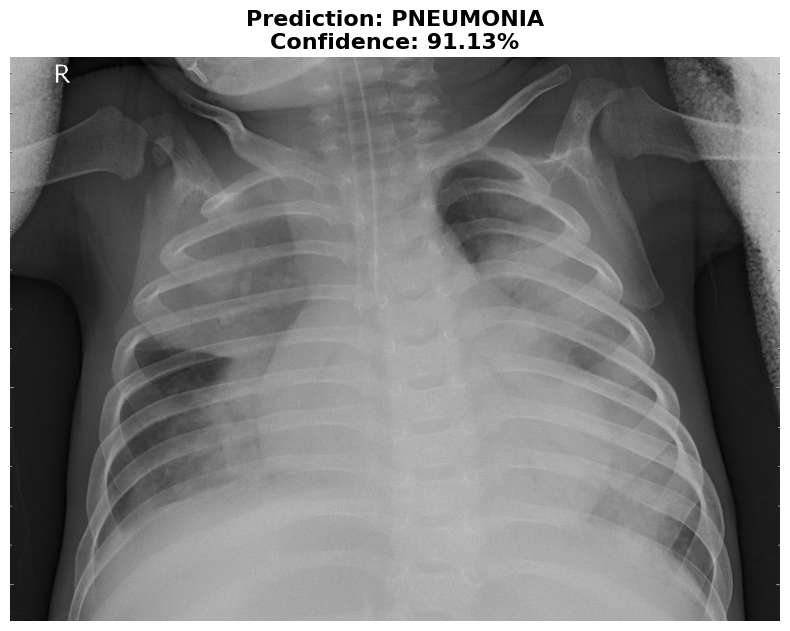

In [30]:
# ============================================================
# CHEST X-RAY PREDICTION
# ============================================================

from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# 1. CLASS NAMES
# ============================================================

class_names = [
    "NORMAL",
    "PNEUMONIA"
]


# ============================================================
# 2. CONFIDENCE THRESHOLD
# ============================================================

threshold = 0.70       # 70%


# ============================================================
# 3. IMAGE PATH
# ============================================================

image_path = "person7_bacteria_24.jpeg"


# ============================================================
# 4. LOAD IMAGE
# ============================================================

original_image = Image.open(
    image_path
).convert("RGB")


# ============================================================
# 5. APPLY SAME TRANSFORM USED DURING TRAINING
# ============================================================

image = transform(original_image)


# Add batch dimension
# [3, 224, 224] → [1, 3, 224, 224]

image = image.unsqueeze(0)


# ============================================================
# 6. MOVE IMAGE TO SAME DEVICE AS MODEL
# ============================================================

image = image.to(device)


# ============================================================
# 7. MODEL PREDICTION
# ============================================================

model.eval()

with torch.no_grad():

    # Forward pass
    output = model(image)

    # Convert logits → probabilities
    probabilities = F.softmax(
        output,
        dim=1
    )

    # Get highest probability
    confidence, predicted_class = torch.max(
        probabilities,
        dim=1
    )


# Convert tensors to Python values

confidence = confidence.item()

predicted_class = predicted_class.item()


# ============================================================
# 8. GET PREDICTED CLASS NAME
# ============================================================

prediction = class_names[predicted_class]


# ============================================================
# 9. GET INDIVIDUAL CLASS PROBABILITIES
# ============================================================

normal_probability = probabilities[0][0].item()

pneumonia_probability = probabilities[0][1].item()


# ============================================================
# 10. CONFIDENCE CHECK
# ============================================================

if confidence >= threshold:

    status = "CONFIDENT PREDICTION"

else:

    status = "LOW CONFIDENCE"


# ============================================================
# 11. PRINT RESULT
# ============================================================

print("=" * 50)
print("          CHEST X-RAY CLASSIFICATION")
print("=" * 50)

print()

print("Prediction:", prediction)

print(
    "Confidence:",
    f"{confidence * 100:.2f}%"
)

print(
    "Status:",
    status
)

print()

print("Class Probabilities:")

print(
    f"NORMAL:    {normal_probability * 100:.2f}%"
)

print(
    f"PNEUMONIA: {pneumonia_probability * 100:.2f}%"
)

print()

print("=" * 50)


# ============================================================
# 12. DISPLAY RESULT ON IMAGE
# ============================================================

if confidence >= threshold:

    title = (
        f"Prediction: {prediction}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

else:

    title = (
        f"LOW CONFIDENCE\n"
        f"Prediction: {prediction}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )


# ============================================================
# 13. SHOW X-RAY
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(original_image)

plt.title(
    title,
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

model_path = "chest_xray_efficientnet_b0_best.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "best_val_loss": best_val_loss,
        "epochs_completed": len(train_losses),
        "image_size": 224
    },
    model_path
)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: chest_xray_efficientnet_b0_best.pth


In [32]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Save best model
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": [
            "NORMAL",
            "PNEUMONIA"
        ],
        "best_val_loss": best_val_loss,
        "epochs_completed": len(train_losses),
        "image_size": 224
    },
    "chest_xray_efficientnet_b0_best.pth"
)

print("✅ Best model saved successfully!")

✅ Best model saved successfully!
